# RQ2: Task Type Sanity Check

## Imports & Load Dataset

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import percent_meeting_condition, conditional_acceptance_rate, df_column_statistics, chi_squared_test

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

filtered_df = pd.read_csv('data/filtered/pull_request.csv')
related_issue_df = pd.read_csv('data/filtered/related_issue.csv')
repo_df = pd.read_csv('data/filtered/repository.csv')
pr_task_type_df = pd.read_csv('data/filtered/pr_task_type.csv')

## Select Subset to Consider for RQ2 (TODO: Check/update these subsets)

In [2]:
# Count PRs per repo
pr_counts = filtered_df.groupby('repo_id').size().reset_index(name='pr_count')
repos_available = repo_df.merge(pr_counts, left_on='id', right_on='repo_id', how='left')

# Sort by PR count and get top 50
top_by_prs = repos_available.nlargest(50, 'pr_count')

# Sort by stars and get top 50
top_by_stars = repos_available.nlargest(50, "stars")
top_by_stars

,id,url,license,full_name,language,forks,stars,repo_id,pr_count
539,41881900,https://api.github.com/repos/microsoft/vscode,MIT,microsoft/vscode,TypeScript,34064,175171,41881900,92
971,70107786,https://api.github.com/repos/vercel/next.js,MIT,vercel/next.js,JavaScript,28968,133524,70107786,4
300,184456251,https://api.github.com/repos/microsoft/PowerToys,MIT,microsoft/PowerToys,C#,7237,121672,184456251,5
313,552661142,https://api.github.com/repos/langchain-ai/lang...,MIT,langchain-ai/langchain,Jupyter Notebook,18400,112624,552661142,5
330,20929025,https://api.github.com/repos/microsoft/TypeScript,Apache-2.0,microsoft/TypeScript,TypeScript,12938,105450,20929025,15
137,34526884,https://api.github.com/repos/ant-design/ant-de...,MIT,ant-design/ant-design,TypeScript,53132,95512,34526884,6
731,599320067,https://api.github.com/repos/langflow-ai/langflow,MIT,langflow-ai/langflow,Python,7227,93294,599320067,3
952,214587193,https://api.github.com/repos/supabase/supabase,Apache-2.0,supabase/supabase,TypeScript,9351,86399,214587193,1
248,612230,https://api.github.com/repos/nvm-sh/nvm,MIT,nvm-sh/nvm,Shell,9115,86116,612230,2
793,1181927,https://api.github.com/repos/bitcoin/bitcoin,MIT,bitcoin/bitcoin,C++,37590,84827,1181927,2


In [3]:
top_by_prs

,id,url,license,full_name,language,forks,stars,repo_id,pr_count
77,839216423,https://api.github.com/repos/liam-hq/liam,Apache-2.0,liam-hq/liam,TypeScript,165,4194,839216423,343
961,710601088,https://api.github.com/repos/crewAIInc/crewAI,MIT,crewAIInc/crewAI,Python,4696,35096,710601088,260
963,941289933,https://api.github.com/repos/antiwork/helper,MIT,antiwork/helper,TypeScript,186,537,941289933,167
572,922805069,https://api.github.com/repos/MontrealAI/AGI-Al...,Apache-2.0,MontrealAI/AGI-Alpha-Agent-v0,Python,58,251,922805069,164
766,955904085,https://api.github.com/repos/antiwork/flexile,MIT,antiwork/flexile,Ruby,236,665,955904085,153
4,845317529,https://api.github.com/repos/giselles-ai/giselle,Apache-2.0,giselles-ai/giselle,TypeScript,36,154,845317529,139
346,696529789,https://api.github.com/repos/dotnet/aspire,MIT,dotnet/aspire,C#,659,4723,696529789,132
998,959682770,https://api.github.com/repos/antiwork/gumroad,MIT,antiwork/gumroad,Ruby,1109,6643,959682770,120
54,633927609,https://api.github.com/repos/promptfoo/promptfoo,MIT,promptfoo/promptfoo,TypeScript,627,7809,633927609,98
664,820087727,https://api.github.com/repos/onlook-dev/onlook,Apache-2.0,onlook-dev/onlook,TypeScript,1419,21192,820087727,94


In [25]:
# Calculate overlap in repos between top by PRs and top by stars
overlap = set(top_by_prs['url']).intersection(set(top_by_stars['url']))
print(f"Number of repos in top 50 by PRs: {len(top_by_prs)}")
print(f"Number of repos in top 50 by stars: {len(top_by_stars)}")
print(f"Number of repos in both top 50 by PRs and top 50 by stars: {len(overlap)}")

# How many PRs in each of the overlapping repos
overlap_pr_counts = top_by_prs[top_by_prs['url'].isin(overlap)][['url', 'pr_count']]
print(overlap_pr_counts)

total_overlapping_prs = overlap_pr_counts['pr_count'].sum()
print(f"Total number of PRs in overlapping repos: {total_overlapping_prs}")

Number of repos in top 50 by PRs: 50
Number of repos in top 50 by stars: 50
Number of repos in both top 50 by PRs and top 50 by stars: 6
                                                   url  pr_count
961      https://api.github.com/repos/crewAIInc/crewAI       260
539      https://api.github.com/repos/microsoft/vscode        92
617  https://api.github.com/repos/appsmithorg/appsmith        51
353         https://api.github.com/repos/gofiber/fiber        50
337     https://api.github.com/repos/dotnet/aspnetcore        39
576  https://api.github.com/repos/browser-use/brows...        32
Total number of PRs in overlapping repos: 524


In [26]:
top_by_stars

,id,url,license,full_name,language,forks,stars,repo_id,pr_count
539,41881900,https://api.github.com/repos/microsoft/vscode,MIT,microsoft/vscode,TypeScript,34064,175171,41881900,92
971,70107786,https://api.github.com/repos/vercel/next.js,MIT,vercel/next.js,JavaScript,28968,133524,70107786,4
300,184456251,https://api.github.com/repos/microsoft/PowerToys,MIT,microsoft/PowerToys,C#,7237,121672,184456251,5
313,552661142,https://api.github.com/repos/langchain-ai/lang...,MIT,langchain-ai/langchain,Jupyter Notebook,18400,112624,552661142,5
330,20929025,https://api.github.com/repos/microsoft/TypeScript,Apache-2.0,microsoft/TypeScript,TypeScript,12938,105450,20929025,15
137,34526884,https://api.github.com/repos/ant-design/ant-de...,MIT,ant-design/ant-design,TypeScript,53132,95512,34526884,6
731,599320067,https://api.github.com/repos/langflow-ai/langflow,MIT,langflow-ai/langflow,Python,7227,93294,599320067,3
952,214587193,https://api.github.com/repos/supabase/supabase,Apache-2.0,supabase/supabase,TypeScript,9351,86399,214587193,1
248,612230,https://api.github.com/repos/nvm-sh/nvm,MIT,nvm-sh/nvm,Shell,9115,86116,612230,2
793,1181927,https://api.github.com/repos/bitcoin/bitcoin,MIT,bitcoin/bitcoin,C++,37590,84827,1181927,2


In [5]:
# Create a union of the top repos by PRs and stars
all_top_repos = set(top_by_prs['url']).union(set(top_by_stars['url']))
print(f"Total unique repos in top 50 by PRs or stars: {len(all_top_repos)}")

all_top_prs = filtered_df[filtered_df['repo_url'].isin(all_top_repos)]
len(all_top_prs)

Total unique repos in top 50 by PRs or stars: 94


3767

In [7]:
# Add task type and confidence to all_top_prs
all_top_prs = all_top_prs.merge(pr_task_type_df[['id', 'type', 'confidence']], left_on='id', right_on='id', how='left')
all_top_prs.head()

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,accepted,rejected,turnaround_time,days_to_close,related_issue,has_open_related_issue,num_commits,num_files_changed,touches_test_file,lines_added,lines_deleted,net_churn,total_churn,num_bot_users,num_human_users,num_total_users,num_comments,num_human_comments,num_bot_comments,num_reviews,num_human_reviews,num_bot_reviews,has_comment,has_review,type,confidence
0,3214555104,16658,Add function signature breaking change detector,<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,Claude_Code,17039389,harupy,closed,2025-07-09T05:35:26Z,2025-07-11T05:13:35Z,2025-07-11T05:13:35Z,136202695,https://api.github.com/repos/mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16658,True,False,171489.0,2.0,False,False,1,3.0,True,620.0,0.0,620.0,620.0,0,2,2,3,3,0,8,8,0,True,True,feat,9
1,3214724259,5489,feat: add comprehensive test coverage for form...,## Summary\n\nThis PR enhances the forms plugi...,Claude_Code,82053242,wtfsayo,closed,2025-07-09T06:43:46Z,2025-07-09T06:44:02Z,2025-07-09T06:44:01Z,826170402,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5489,True,False,16.0,1.0,False,False,4,6.0,True,1013.0,340.0,673.0,1353.0,3,0,3,2,0,2,1,0,1,True,True,feat,10
2,3214876564,5490,fix: critical issues in action chaining implem...,## Summary\n\nThis PR addresses all critical i...,Claude_Code,82053242,wtfsayo,closed,2025-07-09T07:39:31Z,2025-07-09T08:35:49Z,2025-07-09T08:35:49Z,826170402,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5490,True,False,3378.0,1.0,False,False,7,5.0,True,331.0,52.0,279.0,383.0,4,1,5,15,5,10,5,0,5,True,True,fix,10
3,3215868710,2454,feat: add split-pr command for managing large ...,## Issue\n\n- N/A (Enhancement)\n\n## Why is t...,Claude_Code,50833174,NoritakaIkeda,closed,2025-07-09T12:58:34Z,2025-07-10T02:27:04Z,2025-07-10T02:27:03Z,839216423,https://api.github.com/repos/liam-hq/liam,https://github.com/liam-hq/liam/pull/2454,True,False,48510.0,1.0,False,False,2,1.0,False,48.0,0.0,48.0,48.0,6,1,7,6,0,6,3,1,2,True,True,feat,10
4,3222101465,2520,♻️ Refactor database schema design workflow to...,## Issue\r\n\r\n- resolve: #2504\r\n\r\n## Why...,Claude_Code,31152321,MH4GF,closed,2025-07-11T08:45:31Z,2025-07-14T03:57:14Z,2025-07-14T03:57:13Z,839216423,https://api.github.com/repos/liam-hq/liam,https://github.com/liam-hq/liam/pull/2520,True,False,241903.0,3.0,False,False,3,12.0,True,255.0,260.0,-5.0,515.0,5,2,7,6,0,6,12,10,2,True,True,refactor,9


In [8]:
all_top_prs['confidence'].value_counts()

confidence
10    1881
9     1698
8      184
7        4
Name: count, dtype: int64

In [9]:
all_top_prs['type'].value_counts()

type
feat        1350
fix         1120
docs         412
refactor     385
chore        176
test         161
build         51
ci            47
perf          32
style         26
revert         4
other          3
Name: count, dtype: int64

## Randomly Sample Task Type to Create Label Checking Sheets

In [10]:
# Randomly sample 10% of PRs from each task type for manual checking
sampled_prs = all_top_prs.groupby('type').apply(lambda x: x.sample(frac=0.1, random_state=67)).reset_index(drop=True)
sampled_prs[['id', 'html_url', 'type', 'confidence']].head(20)

# Shuffle PRs in the sample
sampled_prs = sampled_prs.sample(frac=1, random_state=67).reset_index(drop=True)

# Check sample is representative of:
# - Distribution of task types
print("Distribution of task types in all_top_prs:")
print(all_top_prs['type'].value_counts())
print("\nDistribution of task types in sampled_prs:")
print(sampled_prs['type'].value_counts())

# - Number of repositories represented
print(f"Number of unique repositories in all_top_prs: {all_top_prs['repo_url'].nunique()}")
print(f"Number of unique repositories in sampled_prs: {sampled_prs['repo_url'].nunique()}")

Distribution of task types in all_top_prs:
type
feat        1350
fix         1120
docs         412
refactor     385
chore        176
test         161
build         51
ci            47
perf          32
style         26
revert         4
other          3
Name: count, dtype: int64

Distribution of task types in sampled_prs:
type
feat        135
fix         112
docs         41
refactor     38
chore        18
test         16
ci            5
build         5
perf          3
style         3
Name: count, dtype: int64
Number of unique repositories in all_top_prs: 94
Number of unique repositories in sampled_prs: 66


/var/folders/gw/jg8766954y92j4x7kpzdhg680000gp/T/ipykernel_45432/3245195504.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_prs = all_top_prs.groupby('type').apply(lambda x: x.sample(frac=0.1, random_state=67)).reset_index(drop=True)


In [19]:
# Create csv file so raters can label the PRs. The csv should have the PR url and a blank column for task type
sample_to_csv = sampled_prs[['html_url']].copy()
sample_to_csv['task_type'] = ''

sample_to_csv.to_csv('sample_prs_rater1.csv', index=False)
sample_to_csv.to_csv('sample_prs_rater2.csv', index=False)


## Manual Labelling Results Checking

In [20]:
# Load completed rater files and merge with original LLM labels
rater1_df = pd.read_csv('rater1.csv').rename(columns={'task_type': 'rater1'})
rater2_df = pd.read_csv('rater2.csv').rename(columns={'task_type': 'rater2'})

ratings_df = rater1_df.merge(rater2_df, on='html_url')
ratings_df = ratings_df.merge(
    sampled_prs[['html_url', 'type', 'confidence']],
    on='html_url'
).rename(columns={'type': 'llm_label'})

print(ratings_df.shape)
ratings_df.head()

(6, 5)


,html_url,rater1,rater2,llm_label,confidence
0,https://github.com/pdfme/pdfme/pull/718,build,chore,refactor,10
1,https://github.com/bruin-data/bruin/pull/830,test,test,fix,10
2,https://github.com/langfuse/langfuse-docs/pull...,fix,fix,fix,10
3,https://github.com/gradio-app/gradio/pull/11601,build,feat,fix,10
4,https://github.com/langfuse/langfuse-docs/pull...,test,test,docs,10


In [21]:
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

# --- Cohen's Kappa (rater1 vs rater2) ---
kappa_r1_r2 = cohen_kappa_score(ratings_df['rater1'], ratings_df['rater2'])
print(f"Cohen's Kappa (Rater 1 vs Rater 2): {kappa_r1_r2:.4f}")

# Rule of thumb interpretation
def interpret_kappa(k):
    if k < 0:    return "Poor (less than chance)"
    elif k < 0.2: return "Slight"
    elif k < 0.4: return "Fair"
    elif k < 0.6: return "Moderate"
    elif k < 0.8: return "Substantial"
    else:         return "Almost Perfect"

print(f"Interpretation: {interpret_kappa(kappa_r1_r2)}")

# --- Raw percent agreement ---
pct_agree_raters = (ratings_df['rater1'] == ratings_df['rater2']).mean()
print(f"Raw agreement (Rater 1 vs Rater 2): {pct_agree_raters:.2%}")

Cohen's Kappa (Rater 1 vs Rater 2): 0.3571
Interpretation: Fair
Raw agreement (Rater 1 vs Rater 2): 50.00%


In [22]:
# --- Cohen's Kappa (each rater vs LLM) ---
kappa_r1_llm = cohen_kappa_score(ratings_df['rater1'], ratings_df['llm_label'])
kappa_r2_llm = cohen_kappa_score(ratings_df['rater2'], ratings_df['llm_label'])

print(f"Cohen's Kappa (Rater 1 vs LLM): {kappa_r1_llm:.4f} ({interpret_kappa(kappa_r1_llm)})")
print(f"Cohen's Kappa (Rater 2 vs LLM): {kappa_r2_llm:.4f} ({interpret_kappa(kappa_r2_llm)})")

# --- Raw percent agreement ---
pct_r1_llm = (ratings_df['rater1'] == ratings_df['llm_label']).mean()
pct_r2_llm = (ratings_df['rater2'] == ratings_df['llm_label']).mean()
print(f"Raw agreement (Rater 1 vs LLM): {pct_r1_llm:.2%}")
print(f"Raw agreement (Rater 2 vs LLM): {pct_r2_llm:.2%}")

# --- Three-way agreement (all three agree) ---
pct_all_agree = (
    (ratings_df['rater1'] == ratings_df['rater2']) & 
    (ratings_df['rater2'] == ratings_df['llm_label'])
).mean()
print(f"Three-way agreement (Rater 1 = Rater 2 = LLM): {pct_all_agree:.2%}")

Cohen's Kappa (Rater 1 vs LLM): 0.0909 (Slight)
Cohen's Kappa (Rater 2 vs LLM): 0.0625 (Slight)
Raw agreement (Rater 1 vs LLM): 16.67%
Raw agreement (Rater 2 vs LLM): 16.67%
Three-way agreement (Rater 1 = Rater 2 = LLM): 16.67%


In [15]:
# Use majority vote as the gold label
# If rater1 == rater2, use that; else fall back to LLM label
def majority_vote(row):
    votes = [row['rater1'], row['rater2'], row['llm_label']]
    from collections import Counter
    return Counter(votes).most_common(1)[0][0]

ratings_df['gold_label'] = ratings_df.apply(majority_vote, axis=1)

# Flag cases where all three disagree (no majority)
all_disagree_mask = (
    (ratings_df['rater1'] != ratings_df['rater2']) &
    (ratings_df['rater2'] != ratings_df['llm_label']) &
    (ratings_df['rater1'] != ratings_df['llm_label'])
)
print(f"Cases with no majority agreement: {all_disagree_mask.sum()}")
ratings_df[all_disagree_mask][['html_url', 'rater1', 'rater2', 'llm_label']]

Cases with no majority agreement: 0


,html_url,rater1,rater2,llm_label


=== Rater 1 vs LLM ===
              precision    recall  f1-score   support

       build       0.00      0.00      0.00         2
       chore       0.00      0.00      0.00         1
          ci       0.00      0.00      0.00         0
        docs       0.00      0.00      0.00         0
        feat       0.00      0.00      0.00         0
         fix       0.33      1.00      0.50         1
       other       0.00      0.00      0.00         0
        perf       0.00      0.00      0.00         0
    refactor       0.00      0.00      0.00         0
      revert       0.00      0.00      0.00         0
       style       0.00      0.00      0.00         0
        test       0.00      0.00      0.00         2

    accuracy                           0.17         6
   macro avg       0.03      0.08      0.04         6
weighted avg       0.06      0.17      0.08         6

=== Rater 2 vs LLM ===
              precision    recall  f1-score   support

       build       0.00      0.0

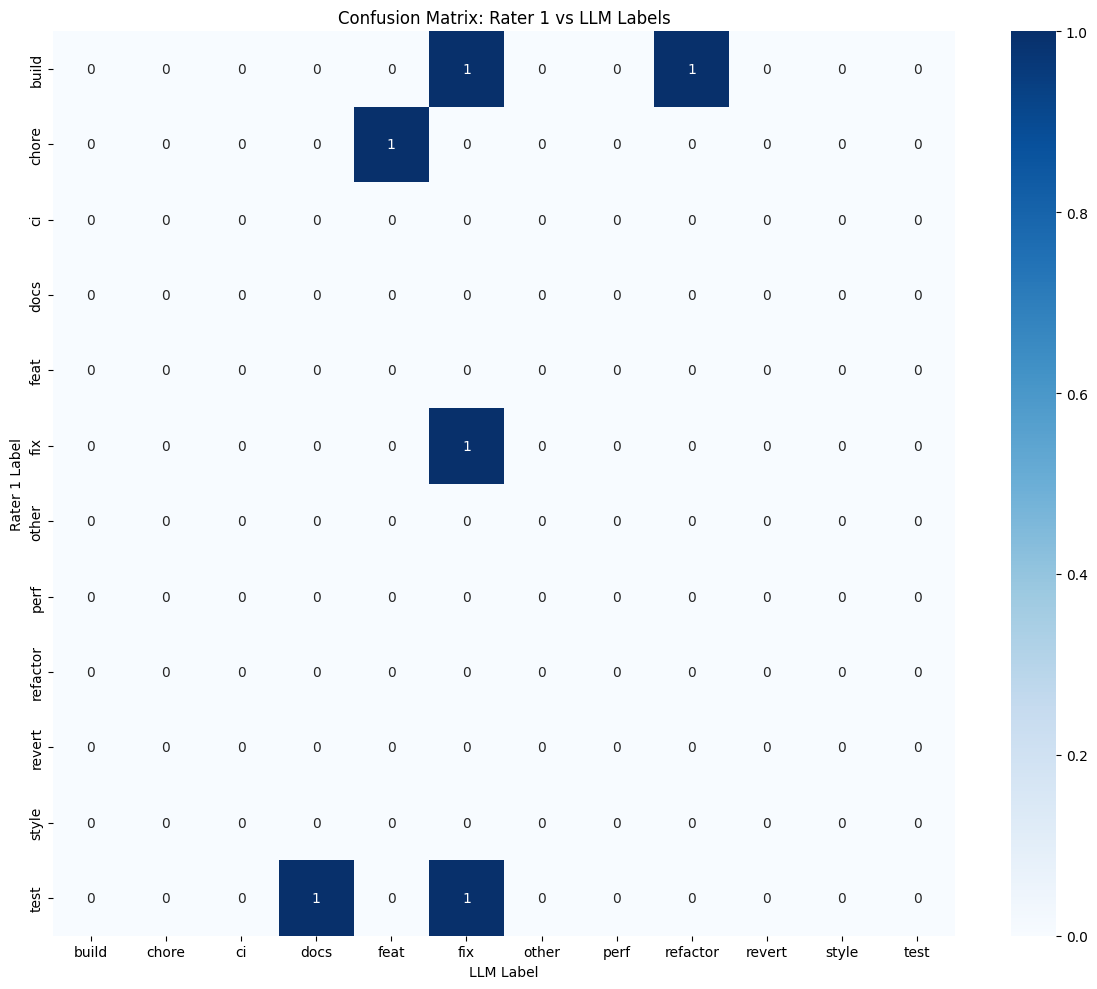

In [23]:
TASK_TYPES = ['build','chore','ci','docs','feat','fix','other','perf','refactor','revert','style','test']

# Per-class precision/recall/F1: raters vs LLM
print("=== Rater 1 vs LLM ===")
print(classification_report(ratings_df['rater1'], ratings_df['llm_label'], labels=TASK_TYPES, zero_division=0))

print("=== Rater 2 vs LLM ===")
print(classification_report(ratings_df['rater2'], ratings_df['llm_label'], labels=TASK_TYPES, zero_division=0))

# Confusion matrix heatmap (Rater 1 vs LLM as example)
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(ratings_df['rater1'], ratings_df['llm_label'], labels=TASK_TYPES)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=TASK_TYPES, yticklabels=TASK_TYPES, ax=ax, cmap='Blues')
ax.set_xlabel('LLM Label')
ax.set_ylabel('Rater 1 Label')
ax.set_title('Confusion Matrix: Rater 1 vs LLM Labels')
plt.tight_layout()
plt.savefig('confusion_matrix_rater1_vs_llm.png')
plt.show()